_texto_

In [1]:
# %pip install pandas
import pandas as pd
import numpy as np


In [2]:

ARQUIVO = r'C:\Users\eduarda.castilho\Documents\UC2_aulas\aula05_UC2\03.BaseDPEvolucaoMensalCisp.csv'
df = pd.read_csv(ARQUIVO, sep = ';', encoding ='iso-8859-1')
df.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        34848 non-null  int64  
 1   mes                         34848 non-null  int64  
 2   ano                         34848 non-null  int64  
 3   mes_ano                     34848 non-null  str    
 4   aisp                        34848 non-null  int64  
 5   risp                        34848 non-null  int64  
 6   munic                       34848 non-null  str    
 7   mcirc                       34848 non-null  int64  
 8   regiao                      34848 non-null  str    
 9   hom_doloso                  34848 non-null  int64  
 10  lesao_corp_morte            34848 non-null  int64  
 11  latrocinio                  34848 non-null  int64  
 12  cvli                        34848 non-null  int64  
 13  hom_por_interv_policial     34848 non-null

In [4]:
df_roubo_veiculo = df['roubo_veiculo']
df_roubo_veiculo.head()

0     5
1     9
2    11
3    27
4    23
Name: roubo_veiculo, dtype: int64

In [11]:
assimetria = df['roubo_veiculo'].skew()
curtose = df['roubo_veiculo'].kurtosis()

print(f'Assimetria: {assimetria:.4f}')
print(f'Curtose: {curtose:.4f}')

Assimetria: 2.8412
Curtose: 10.9725


In [ ]:
#%pip install matplotlib

import matplotlib.pyplot as plt

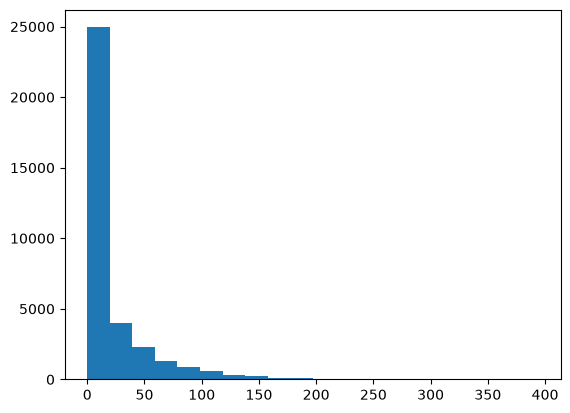

In [16]:
plt.hist(df['roubo_veiculo'], bins = 20)
plt.show()

In [5]:
df_roubo_munic = df[['munic', 'roubo_veiculo']]

df_roubo_munic_agg = (
    df_roubo_munic.groupby('munic')
    .sum()
    .reset_index()
    .sort_values(by = 'roubo_veiculo', ascending=False)
)
df_roubo_munic_agg

,munic,roubo_veiculo
68,Rio de Janeiro,372584
23,Duque de Caxias,62574
78,São Gonçalo,52539
50,Nova Iguaçu,40235
81,São João de Meriti,30151
...,...,...
66,Rio das Flores,8
58,Porciúncula,7
46,Natividade;Varre-Sai,6
45,Miracema,6


In [6]:
roubo_array = np.array(df_roubo_munic_agg['roubo_veiculo'])

media = np.mean(roubo_array)
mediana = np.median(roubo_array)
dif_media_mediana = (media - mediana)
div_media_mediana = (media/mediana)

desvio = np.std(roubo_array)
cv = (desvio/media)

q1 = np.percentile(roubo_array, 25)
q3 = np.percentile(roubo_array, 75)
iqr = (q3 - q1)
max = np.max(roubo_array)
min = np.min(roubo_array)
amplitude = (max - min)

In [7]:
print(f'MÉDIA: {media:.2f}')
print(f'MEDIANA/Q2: {mediana:.2f}')
print(f'Diferença Média-Mediana: {dif_media_mediana:.2f}')
print(f'Razão Média/Mediana: {div_media_mediana:.2f}')
print(f'Desvio Padrão:{desvio}')
print(f'CV: {cv:.2f}')
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Máximo: {max:.2f}')
print(f'Mínimo: {min:.2f}')
print(f'Amplitude: {amplitude:.2f}')


MÉDIA: 7448.24
MEDIANA/Q2: 247.50
Diferença Média-Mediana: 7200.74
Razão Média/Mediana: 30.09
Desvio Padrão:40044.55206622608
CV: 5.38
Q1: 47.00
Q3: 989.50
IQR: 942.50
Máximo: 372584.00
Mínimo: 2.00
Amplitude: 372582.00


In [17]:
assimetria = df_roubo_munic_agg['roubo_veiculo'].skew()
kurt = df_roubo_munic_agg['roubo_veiculo'].kurtosis()

print(f'Assimetria por município: {assimetria:.4f}')
print(f'Curtose por município: {kurt:.4f}')

Assimetria por município: 8.6170
Curtose por município: 78.2164


In [ ]:
'''
Assimetria:
   if assimetria > 0.5:
        ASSIMETRIA POSITIVA
        Inferencia: Tem causa longa para a direita -> grandes valores são minoria, porém, muito expressivos, o que puxa o valor médio para cima
   if assimetria < -0.5:
        ASSIMETRIA NEGATIVA
        Inferencia: Tem cauda longa para a esquerda -> Valor médio é puxado para baixo por alguns valores baixos que não são recorrentes.
   else:
        SIMÉTRICA 
        Inferencia: distribuição equilibrada -> média e mediana próximas.
'''

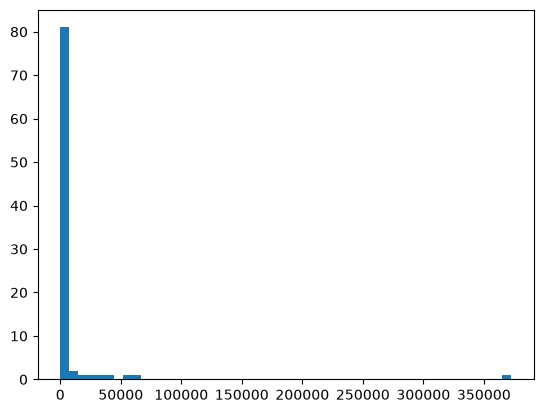

In [20]:
plt.hist(df_roubo_munic_agg['roubo_veiculo'], bins = 50)
plt.show()

In [8]:
df_roubo_ano = df[['ano', 'roubo_veiculo']]

df_roubo_ano_agg = (
    df_roubo_ano.groupby('ano')
    .sum()
    .reset_index()
    .sort_values(by = 'roubo_veiculo', ascending=False)
)
df_roubo_ano_agg

,ano,roubo_veiculo
14,2017,54366
15,2018,52097
13,2016,41696
16,2019,39749
3,2006,34324
0,2003,33531
2,2005,32690
11,2014,32651
1,2004,32408
4,2007,31490


In [9]:
roubo_array_ano = np.array(df_roubo_ano_agg['roubo_veiculo'])

media = np.mean(roubo_array_ano)
mediana = np.median(roubo_array_ano)
dif_media_mediana = (media - mediana)
div_media_mediana = (media/mediana)

desvio = np.std(roubo_array_ano)
cv = (desvio/media)

q1 = np.percentile(roubo_array_ano, 25)
q3 = np.percentile(roubo_array_ano, 75)
iqr = (q3 - q1)
max = np.max(roubo_array_ano)
min = np.min(roubo_array_ano)
amplitude = (max - min)

In [10]:
print(f'MÉDIA: {media:.2f}')
print(f'MEDIANA/Q2: {mediana:.2f}')
print(f'Diferença Média-Mediana: {dif_media_mediana:.2f}')
print(f'Razão Média/Mediana: {div_media_mediana:.2f}')
print(f'Desvio Padrão:{desvio:.2f}')
print(f'CV: {cv:.2f}')
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Máximo: {max:.2f}')
print(f'Mínimo: {min:.2f}')
print(f'Amplitude: {amplitude:.2f}')

MÉDIA: 30470.09
MEDIANA/Q2: 29518.50
Diferença Média-Mediana: 951.59
Razão Média/Mediana: 1.03
Desvio Padrão:9620.58
CV: 0.32
Q1: 24508.00
Q3: 33320.75
IQR: 8812.75
Máximo: 54366.00
Mínimo: 15327.00
Amplitude: 39039.00
